<a href="https://colab.research.google.com/github/tphlabs/Lab2_I_manual/blob/main/Lab2_Inductance_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab2 Inductance

Evgeny Kolonsky Feb - June 2023 - 2025

v0.2


In [66]:
!pip install uncertainties

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cumtrapz
from scipy.stats import linregress
import scipy.constants
from uncertainties import ufloat

# Model

Magnetic field $B$ of the constant cylindrical magnet of radius $b$ and half-height $l$ as a function of axial distance $z$ from center can be approximated as a field of same size solenoid with current $I$ and number of windings $n$:
\begin{equation}
B(z)=\frac{\mu_0 \, NI}{2}\left(\frac{z+l}{\sqrt{\left(z+l\right)^2+b^2}}-\frac{z-l}{\sqrt{\left(z-l\right)^2+b^2}}\right). \tag{1}
\end{equation}
Denote  $B_r \equiv \mu_0 M \equiv \mu_0 N I $ as magnetic **remanenence**, [see definition](http://hyperphysics.phy-astr.gsu.edu/hbase/Solids/magperm.html#c1) and [reference values](https://www.magmamagnets.com/wp-content/uploads/2017/02/neodymium-magnetic-characterstics.pdf) for Neodium magnets it is of order of 1 Tesla, may be less for deteriorated samples.  


Magnetic flux $\Phi$ throug a coil  perpendicilar to axis $z$ is
$$
\Phi = A \cdot n \cdot B  ,
\tag{2}
$$
here $n$ is number of windings in the coil, $A$ is cross-section of the coil.

When the magnet moves along axis $z$, the distance $z$ changes with time, and electromotive force $\epsilon$ is inducted in the coil:
$$
\frac{\partial \Phi}{\partial t} = \epsilon(t)
\tag{3}
$$.

We suggest the magnets falls with constant acceleration, hence
$$
z(t) = z_0 + v_0 t + a \frac{t^2}{2}.
\tag{4}
$$


# Constants


In [68]:
mu0 = scipy.constants.mu_0
l = 2e-2 / 2 # m length of magnet
b = 1e-2 #m radius of magnet
d = 35e-3 #m, coil diameter
A = np.pi * d**2 / 4 # square of the coil
n = 50 # coil 2 number of windings of the coil
n1 = 17 # coil 1 number of windings
origin = 21 # cm
Br_reference = 1.30 # T, +- 0.02, N42 https://www.magmamagnets.com/wp-content/uploads/2017/02/neodymium-magnetic-characterstics.pdf

# Functions

In [69]:
def get_trace(num):
    fname = f'{num:d}.csv'
    t, Vx, Vy = np.genfromtxt(fname, skip_header=1,
                              delimiter=',').T
    return t, Vx, Vy

def get_phi(t, Vx, Vy):
    #Vx -= np.mean(Vx[-10:-1]) #get rid of offset
    #Vy -= np.mean(Vy[-10:-1])    #get rid of offset

    phix = cumtrapz(Vx, t, initial=0)
    phiy = cumtrapz(Vy, t, initial=0)
    return phix, phiy

def get_timedist(t, Vx, Vy):
    phix, phiy = get_phi(t, Vx, Vy)
    t1 = t[np.argmax(np.abs(phix))]
    t2 = t[np.argmax(np.abs(phiy))]
    return t1, t2

def geometric_factor(z):
    def slil(z, l):
      return (z + l) / np.sqrt((z + l)**2 + b**2)
    s1 = slil(z, l)
    s2 = - slil(z, -l)
    return (s1 + s2) /2

# Direct measurements

Average magnetization measured by Teslameter = (1.093+/-0.009)e+00, T, offset 1.8e-03


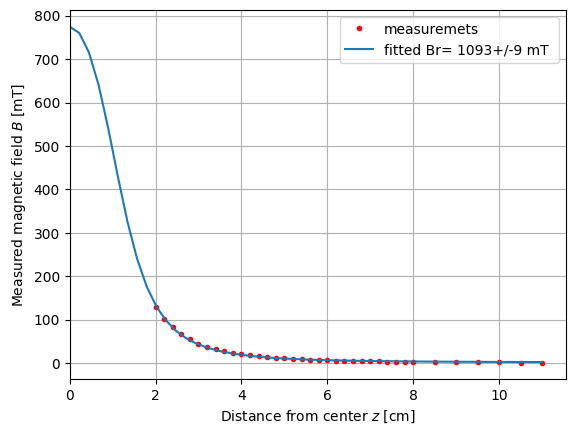

In [70]:
filename = 'Magnetic_Field_Measurement.csv'
z_measured, B_measured =  np.genfromtxt(filename, skip_header=1, delimiter=',',unpack=True)

linz = geometric_factor(z_measured)
fit = linregress(linz,  B_measured )
plt.plot(z_measured*1e2, 1e3*B_measured, 'r.', label='measuremets')
plt.xlabel(r'Distance from center $z$ [cm]')
plt.ylabel(r'Measured magnetic field $B$ [mT]')
plt.grid()

Br = fit.slope
Br_offset = fit.intercept
Br_err = fit.stderr
Br_measured = ufloat(Br, Br_err)
z_dense = np.linspace(0, z_measured.max())
plt.plot(z_dense*1e2, 1e3*  (Br  *geometric_factor(z_dense) + Br_offset), label=f'fitted Br= {Br_measured*1e3:.1u} mT ')
plt.xlim(left=0)
plt.legend()



print(f"Average magnetization measured by Teslameter = {Br_measured:.1ue}, T, offset {Br_offset:.1e}")

# Change height of free fall and get kinematics



In [71]:
nums = range(40, 64, 2)
h_fall = (np.array(nums) - origin) * 1e-2 #m
t_fall = np.zeros(h_fall.size)
for i, num in enumerate(nums):
    t, vx , vy = get_trace(num)
    phx, phy = get_phi(t, vx, vy)
    t1, t2 = get_timedist(t, vx, vy)
    t_fall[i] = t2 - t1





## Linear approximation

$$ {h \over t} = v_0 + a t$$

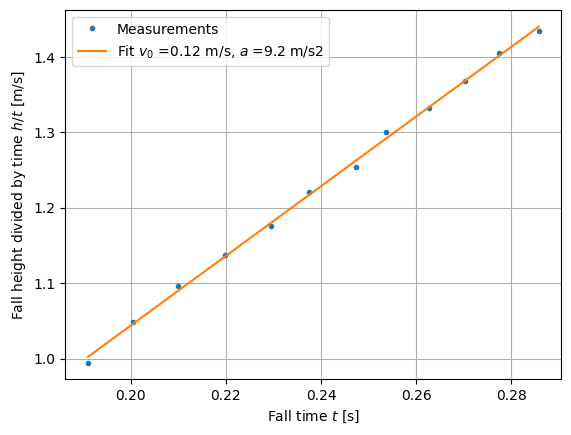

In [72]:
plt.plot(t_fall, h_fall/t_fall, '.', label='Measurements')

fit = linregress(t_fall, h_fall/t_fall)
v0 = fit.intercept
acc = fit.slope * 2

plt.plot(t_fall, fit.slope*t_fall + fit.intercept, label=rf'Fit $v_0$ ={v0:.2f} m/s, $a$ ={acc:.1f} m/s2')
plt.xlabel(r'Fall time $t$ [s]')
plt.ylabel(r'Fall height divided by time $h/t$ [m/s]')
plt.grid()
plt.legend()

plt.show();

# Transform time to distanse, flux on second coil to magnetic field

 Magnetization calculated from scope data  (3.9+/-0.2)e+02 mT
 Magnetization taken by Teslameter  (1.093+/-0.009)e+03 mT


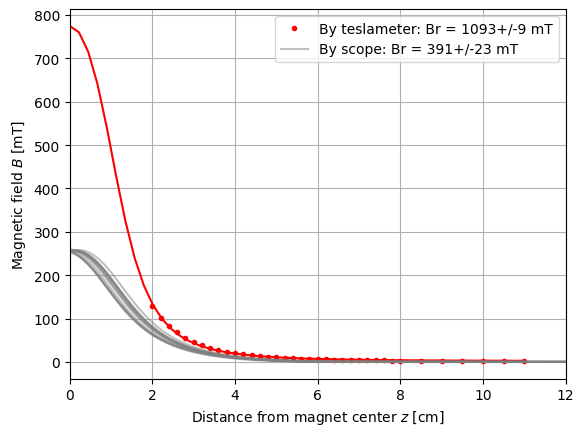

In [73]:
# plot direct measurements
plt.plot(z_measured*1e2, B_measured*1e3, 'r.', label=f'By teslameter: Br = {Br_measured*1e3} mT')
z_dense = np.linspace(0, z_measured.max())
plt.plot(z_dense*1e2, 1e3*  (Br_measured.n  *geometric_factor(z_dense) + Br_offset), color='r')


nums = range(40, 64, 2)
Brs = np.zeros(len(nums))
for i, num in enumerate(nums):
    t, vx , vy = get_trace(num)
    phx, phy = get_phi(t, vx, vy)
    t0, t1 = get_timedist(t, vx, vy)
    # convert flux to magnetic field
    B = phy / n / A
    # convert time to distance
    # consider axis z directed up
    z = h_fall[i] - v0 * (t-t0) - acc* (t-t0)**2 /2
    linz = geometric_factor(z)
    filter = (t > t0) & (t < t1) # motion between two coils
    fit = linregress(linz[filter], B[filter] )
    Brs[i] = fit.slope
    plt.plot(z[filter]*1e2, B[filter]*1e3 , color='gray', alpha=0.5)




plt.xlabel(r'Distance from magnet center $z$ [cm]')
plt.ylabel(r'Magnetic field $B$ [mT]')
plt.grid()
plt.xlim(0, 12)


Br = ufloat(Brs.mean(), Brs.std())
plt.plot(z[filter]*1e2, B[filter]*1e3 , color='gray', alpha=0.5, label=f'By scope: Br = {Br*1e3} mT')
#plt.ylim(0, 300)
#plt.yscale('log')
plt.legend()

print(f' Magnetization calculated from scope data  {Br*1e3:.1ue} mT')
print(f' Magnetization taken by Teslameter  {Br_measured*1e3:.1ue} mT')

 Magnetization calculated from scope data  (3.94+/-0.03)e+02 mT
 Magnetization taken by Teslameter  (1.093+/-0.009)e+03 mT


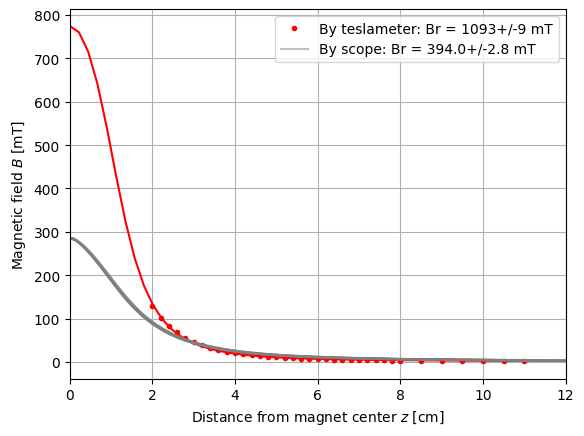

In [89]:
# plot direct measurements
plt.plot(z_measured*1e2, B_measured*1e3, 'r.', label=f'By teslameter: Br = {Br_measured*1e3} mT')
z_dense = np.linspace(0, z_measured.max())
plt.plot(z_dense*1e2, 1e3*  (Br_measured.n  *geometric_factor(z_dense) + Br_offset), color='r')


nums = range(40, 64, 2)
Brs = np.zeros(len(nums))
for i, num in enumerate(nums):
    t, vx , vy = get_trace(num)
    phx, phy = get_phi(t, vx, vy)
    phx -= phx[-1]
    t0, t1 = get_timedist(t, vx, vy)
    # convert flux to magnetic field
    B = phx / n1 / A
    # convert time to distance
    # consider axis z directed up
    z =  v0 * (t-t0) + acc* (t-t0)**2 /2
    linz = geometric_factor(z)
    filter = (t > t0) & (t < t1) # motion between two coils
    fit = linregress(linz[filter], B[filter] )
    Brs[i] = fit.slope
    plt.plot(z[filter]*1e2, B[filter]*1e3 , color='gray', alpha=0.5)




plt.xlabel(r'Distance from magnet center $z$ [cm]')
plt.ylabel(r'Magnetic field $B$ [mT]')
plt.grid()
plt.xlim(0, 12)


Br = ufloat(Brs.mean(), Brs.std())
plt.plot(z[filter]*1e2, B[filter]*1e3 , color='gray', alpha=0.5, label=f'By scope: Br = {Br*1e3} mT')
#plt.ylim(0, 300)
#plt.yscale('log')
plt.legend()

print(f' Magnetization calculated from scope data  {Br*1e3:.1ue} mT')
print(f' Magnetization taken by Teslameter  {Br_measured*1e3:.1ue} mT')